# 12 Catalog and I/O

Catalogs are for browse/select/extract. AnalysisObjects are for computation.


## Imports

Imports are kept separate so the instructional cells can focus on TAL semantics.


In [1]:
from __future__ import annotations

import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from IPython.display import display

import tal
from tal.catalog import Catalog
from tal.io import CsvIngestOptions, read_csv_logs_catalog, write_csv_logs

from pathlib import Path
import sys

_release_dir = Path.cwd()
if not (_release_dir / '_helpers.py').exists():
    candidate = Path.cwd() / 'examples' / 'release'
    if candidate.exists():
        _release_dir = candidate
if str(_release_dir) not in sys.path:
    sys.path.append(str(_release_dir))

from _helpers import (
    build_framegraph_spatial_payloads,
    build_topology_edge_payloads,
    compact_dataset,
    display_result,
    explain_expected_failure,
    make_imu_gps_alignment_aos,
    make_kinematics_demo_objects,
    make_pose_demo_objects,
    show_ao,
    summarize_ao,
)


## Build a small DataTree-backed catalog

The catalog provides a metadata-aware browsing layer over grouped data.


In [2]:
root = xr.DataTree(name='root')

ds_a = xr.Dataset({'y': ('time', np.sin(np.linspace(0.0, 1.0, 6)))}, coords={'time': np.linspace(0.0, 1.0, 6)})
ds_a.attrs['status'] = 'pass'

ds_b = xr.Dataset({'y': ('time', np.sin(np.linspace(0.2, 1.2, 4)))}, coords={'time': np.linspace(0.2, 1.2, 4)})
ds_b.attrs['status'] = 'fail'

root['trial_a'] = xr.DataTree(ds_a)
root['trial_b'] = xr.DataTree(ds_b)

cat = Catalog(root)
cat


Catalog(backend='datatree', batch_dim='group', groups=2)

## Browse/filter before compute

`query` narrows the catalog. `extract` materializes an AO when you are ready to analyze values.


#### catalog rows with status=fail

,field,value
0,type,AnalysisObject
1,dims,"{'group': 1, 'time': 4}"
2,data_vars,[y]
3,coords,"[time, group, status]"
4,batch_dims,()
5,sequence_dim,None
6,core_dims,()
7,param_coord,None
8,sequence_size_coord,None
9,frames,None


,kind,name,dims,shape,dtype
0,data_var,y,"(group, time)","(1, 4)",float64
1,coord,time,"(time,)","(4,)",float64
2,coord,group,"(group,)","(1,)",object
3,coord,status,"(group,)","(1,)",object


#### extracted AO ready for analysis

,field,value
0,type,AnalysisObject
1,dims,"{'group': 1, 'sample': 4}"
2,data_vars,[y]
3,coords,"[status, group, time]"
4,batch_dims,"(group,)"
5,sequence_dim,sample
6,core_dims,()
7,param_coord,time
8,sequence_size_coord,None
9,frames,None


,kind,name,dims,shape,dtype
0,data_var,y,"(group, sample)","(1, 4)",float64
1,coord,status,"(group,)","(1,)",object
2,coord,group,"(group,)","(1,)",object
3,coord,time,"(sample,)","(4,)",float64


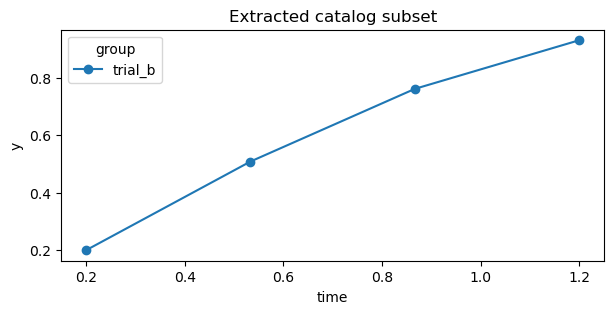

In [3]:
failing = cat.query(status='fail')
ao = failing.extract('y')
ao = tal.AnalysisObject.from_data(
    ao.as_dataset().rename_dims({'time': 'sample'}),
    sequence_dim='sample',
    batch_dims=['group'],
    core_dims=[],
    param_coord='time',
)

display_result('catalog rows with status=fail', failing.extract('y'), data=False)
display_result('extracted AO ready for analysis', ao, data=False)

fig, ax = plt.subplots(figsize=(7, 3))
ds = ao.unsafe_data
for group in ds['group'].to_numpy():
    ax.plot(ds['time'], ds['y'].sel(group=group), marker='o', label=str(group))
ax.set(title='Extracted catalog subset', xlabel='time', ylabel='y')
ax.legend(title='group', loc='best')


## Visual sanity check

A small plot confirms the selected payload before persistence roundtrips.


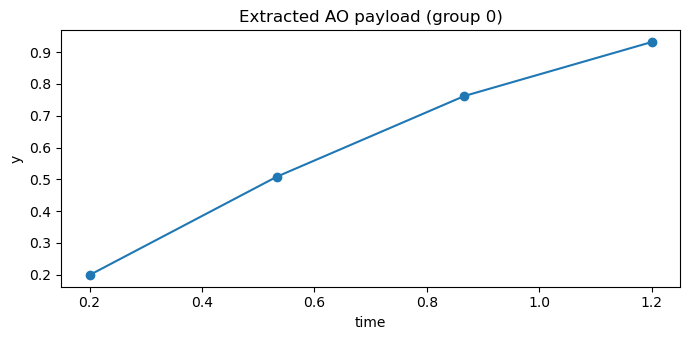

In [4]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
    print('Plot skipped: matplotlib is not installed.')

if plt is not None:
    var = next(iter(ao.as_dataset().data_vars))
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(ao.as_dataset()['time'].values, ao.as_dataset()[var].isel(group=0).values, marker='o')
    ax.set_title('Extracted AO payload (group 0)')
    ax.set_xlabel('time')
    ax.set_ylabel(var)
    plt.tight_layout()
    plt.show()


## CSV roundtrip with log adapters

CSV is useful for interoperability, but schema metadata must be promoted or carried carefully.


In [5]:
with tempfile.TemporaryDirectory() as td:
    out_dir = Path(td) / 'csv_out'
    paths = write_csv_logs(ao, str(out_dir))

    reloaded = read_csv_logs_catalog(
        str(out_dir / '*.csv'),
        opts=CsvIngestOptions(time_col='time'),
    )

    {
        'written_files': [Path(p).name for p in paths],
        'reloaded_backend': reloaded.backend,
        'reloaded_groups': reloaded.group_labels,
    }


## Why Zarr?

Zarr preserves N-dimensional structure and is the preferred AO-direct persistence surface for richer TAL data.


#### loaded AO from Zarr

,field,value
0,type,AnalysisObject
1,dims,"{'group': 1, 'sample': 4}"
2,data_vars,[y]
3,coords,"[group, status, time]"
4,batch_dims,"(group,)"
5,sequence_dim,sample
6,core_dims,()
7,param_coord,time
8,sequence_size_coord,None
9,frames,None


,kind,name,dims,shape,dtype
0,data_var,y,"(group, sample)","(1, 4)",float64
1,coord,group,"(group,)","(1,)",object
2,coord,status,"(group,)","(1,)",object
3,coord,time,"(sample,)","(4,)",float64


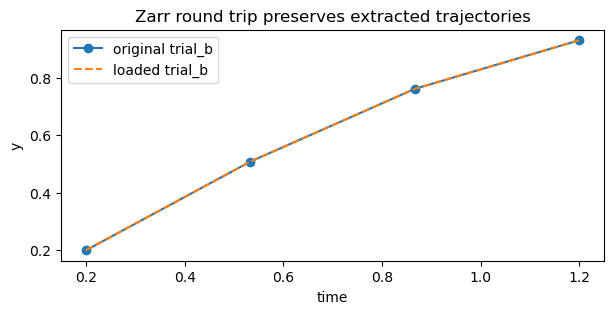

In [8]:
import warnings
from zarr.errors import ZarrUserWarning
warnings.filterwarnings("ignore", category=ZarrUserWarning, message=".*Consolidated metadata is currently not part in the Zarr format 3 specification.*")

with tempfile.TemporaryDirectory() as td:
    store = Path(td) / 'example.zarr'

    ao0 = ao
    ao0.io.to_zarr(str(store))
    ao1 = tal.AnalysisObject.from_zarr(str(store))

    display_result('loaded AO from Zarr', ao1, data=False)

    fig, ax = plt.subplots(figsize=(7, 3))
    for group in ao0.unsafe_data['group'].to_numpy():
        original = ao0.unsafe_data['y'].sel(group=group)
        loaded = ao1.unsafe_data['y'].sel(group=group)
        ax.plot(ao0.unsafe_data['time'], original, marker='o', label=f'original {group}')
        ax.plot(ao1.unsafe_data['time'], loaded, linestyle='--', label=f'loaded {group}')
    ax.set(title='Zarr round trip preserves extracted trajectories', xlabel='time', ylabel='y')
    ax.legend(loc='best')


## AO-direct Zarr roundtrip

This checks that AO data and schema survive a write/read cycle.


In [7]:
try:
    # Example only: replace with a real bag path when `rosbags` is installed.
    # cat_ros = tal.io.read_ros_logs_catalog('/path/to/data.bag')
    import rosbags  # type: ignore  # noqa: F401
    print('rosbags is installed; run tal.io.read_ros_logs_catalog(...) with your local file path.')
except Exception:
    print('rosbags is not installed here; keeping this as a guarded usage pattern.')


rosbags is not installed here; keeping this as a guarded usage pattern.


## ROS import pattern

ROS ingestion is optional and dependency-guarded. The call shape is shown without requiring a local bag file.


## Serialization semantics

TAL persists structural semantics such as roles and metadata. Runtime operation policy stays in code.


## Takeaways

- Browse/query with catalogs.
- Extract AOs for numeric analysis.
- Persist AOs directly when you need schema-preserving roundtrips.

**Exercise:** query a different `status` value, extract it, and save it to Zarr.
